## Notebook 02: EDA & Risk Factor Analysis

**OBJECTIVE:** Understand the distribution of key variables and identify patterns

**BUSINESS QUESTIONS:**
1. What are the primary risk factors driving default?
2. How do key variables distribute across the portfolio?
3. Are there any concerning patterns or outliers?

**REGULATORY CONTEXT:**
- SR 11-7: Outcomes analysis - Understand data distributions
- IFRS 9: Risk driver identification
- OSFI E-23: Data quality documentation

In Notebook 02, I explored the data to understand what drives mortgage defaults.

1. **I started by loading the clean dataset from Notebook 01 and checking that all the enhanced features were present — the PD-LGD estimates, delinquency states, and non-linear risk factors.**

2. **Then I calculated univariate statistics — the mean, median, and distribution of each key variable. I wanted to understand the data before modeling.**

3. **I analyzed the PD-LGD correlation — it was positive (0.119), which is consistent with reality. Higher PD loans have higher LGD. This validated the data quality.**

4. **I then segmented the portfolio by FICO, LTV, property type, and loan age. I found that Mobile Homes have the highest default rate (2.35%) — this is a high-risk segment that needs special attention.**

5. **The correlation analysis confirmed that FICO is the strongest predictor of default (correlation: -0.137). LTV, DTI, and loan age are also significant.**

6. **I also did a vintage analysis — loans from 2023 have a higher default rate than loans from 2021. This could reflect rising interest rates or economic conditions.**

7. **Finally, I used boxplots and t-tests to test whether each risk factor differs between performing and defaulted loans. All were statistically significant, meaning the differences are real, not random.**
    
8. **I documented the limitations — statistical significance doesn't always mean business significance, and correlation doesn't imply causation.**

9. **The output is a summary file that captures all the key findings for stakeholders.**

In [1]:
"""
===============================================================================
FANNIE MAE IFRS 9 COMPLIANCE FRAMEWORK
NOTEBOOK 02: EDA & RISK FACTOR ANALYSIS
===============================================================================

AUTHOR: [Your Name]
DATE: [Current Date]
VERSION: 2.0 (Revised)

PURPOSE:
--------
Perform exploratory data analysis and risk factor identification for the
Fannie Mae mortgage portfolio. This notebook quantifies the relationship
between key risk drivers (FICO, LTV, DTI, age, vintage) and default
probability. It also validates the PD-LGD correlation structure and
identifies segments with elevated risk.

INPUTS:
-------
- data/fannie_mae_final_clean.csv : Cleaned dataset with PD-LGD estimates
                                   from Notebook 01
- data/assumptions_register.csv   : Central assumptions register

OUTPUTS:
--------
- outputs/univariate_analysis.png         : Univariate statistics visualization
- outputs/correlation_heatmap.png         : Correlation matrix
- outputs/vintage_analysis.png            : Vintage performance visualization
- outputs/eda_boxplot_analysis.png        : Boxplot analysis by default status
- outputs/pd_lgd_correlation_analysis.png : PD-LGD correlation visualization
- outputs/eda_analysis_summary.txt        : Summary of EDA findings
- logs/eda_audit_trail_{RUN_ID}.log      : Audit trail

REGULATORY CONTEXT:
-------------------
- OSFI E-23 s.4.3: Data quality and integrity assessment
- OSFI E-23 s.4.2: Documentation of model development
- IFRS 9: Risk driver identification for PD/LGD calibration
- SR 11-7: Outcomes analysis and model validation
- ECOA: Fair lending (protected attributes analysis)

DATASET CAVEAT (REFERENCED):
----------------------------
This notebook uses the dataset described in Notebook 01. As stated there,
this project uses public Fannie Mae data as a PROXY for proprietary bank data.
All conclusions are illustrative and demonstrate methodology, not actual
portfolio performance.

For the full caveat, see Notebook 01 — Section 2: CECL vs IFRS 9 Context.

US/CANADA APPLICABILITY GAP (REFERENCED):
-----------------------------------------
For important differences between US and Canadian mortgage markets, and the
implications for this analysis, see Notebook 01 — Section 2.1:
US/Canada Applicability Gap.

===============================================================================
"""

'\n===============================================================================\nFANNIE MAE IFRS 9 COMPLIANCE FRAMEWORK\nNOTEBOOK 02: EDA & RISK FACTOR ANALYSIS\n===============================================================================\n\nAUTHOR: [Your Name]\nDATE: [Current Date]\nVERSION: 2.0 (Revised)\n\nPURPOSE:\n--------\nPerform exploratory data analysis and risk factor identification for the\nFannie Mae mortgage portfolio. This notebook quantifies the relationship\nbetween key risk drivers (FICO, LTV, DTI, age, vintage) and default\nprobability. It also validates the PD-LGD correlation structure and\nidentifies segments with elevated risk.\n\nINPUTS:\n-------\n- data/fannie_mae_final_clean.csv : Cleaned dataset with PD-LGD estimates\n                                   from Notebook 01\n- data/assumptions_register.csv   : Central assumptions register\n\nOUTPUTS:\n--------\n- outputs/univariate_analysis.png         : Univariate statistics visualization\n- outputs/correlati

#### What It Means

This is a professional notebook header that tells anyone opening the notebook:

- What this notebook does (EDA and risk factor analysis)
- What it needs (the clean dataset from Notebook 01)
- What it produces (visualizations, summary files)
- What regulations apply (OSFI E-23, IFRS 9, SR 11-7, ECOA)
- What the limitations are (proxy data, US/Canada gap)

#### Why This Decision Was Made
- **Why a detailed header?** - In a regulatory environment, documentation is mandatory (OSFI E-23 s.4.2). A header tells a reviewer immediately what this notebook does and where it fits.
- **Why list inputs and outputs?** - This creates traceability — you can see the data lineage. Notebook 01 produces the input; Notebook 02 produces outputs for Notebook 03.
- **Why list regulatory context** - This shows you're regulatory-aware. You're not just doing analysis — you're doing it to meet specific regulatory requirements.
- **Why include the dataset caveat?** - This is honesty — you're not claiming this is real bank data. You reference Notebook 01 for the full caveat, so you don't repeat it.

**I try to document my work professionally. I understand the regulatory context and I am honest about limitations.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
from datetime import datetime
import os
import sys
from scipy.stats import skew, kurtosis, chi2_contingency, ttest_ind

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

### Univariate Analysis
1. Variables to Analyze: Focus on key risk drivers (not all 167 columns)
2. Distribution Binning: Adaptive for continuous variables (better visualization)
3. Outlier Threshold: 3x IQR for financial data (less sensitive, captures true outliers)

### SETUP AUDIT TRAIL

In [3]:
def setup_audit_logger(run_id=None):
    """Set up comprehensive audit trail logging."""
    if run_id is None:
        run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    os.makedirs('logs', exist_ok=True)
    
    logger = logging.getLogger(f"eda_analysis_{run_id}")
    logger.setLevel(logging.INFO)
    
    if logger.hasHandlers():
        logger.handlers.clear()
    
    handler = logging.FileHandler(f"logs/eda_audit_trail_{run_id}.log", encoding='utf-8')
    formatter = logging.Formatter(
        '%(asctime)s | %(levelname)s | %(message)s', 
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    handler.setFormatter(formatter)
    logger.addHandler(handler)
    
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)
    
    return logger, run_id

audit_logger, RUN_ID = setup_audit_logger()
audit_logger.info("="*60)
audit_logger.info("NOTEBOOK 02: EDA & RISK FACTOR ANALYSIS")
audit_logger.info(f"RUN ID: {RUN_ID}")
audit_logger.info("="*60)

print("\n✅ Audit trail initialized: logs/eda_audit_trail_{RUN_ID}.log".format(RUN_ID=RUN_ID))

2026-09-07 18:04:00 | INFO | ============================================================
2026-09-07 18:04:00 | INFO | NOTEBOOK 02: EDA & RISK FACTOR ANALYSIS
2026-09-07 18:04:00 | INFO | RUN ID: 20260907_180400
2026-09-07 18:04:00 | INFO | ============================================================

✅ Audit trail initialized: logs/eda_audit_trail_20260907_180400.log


#### What It Means

Same as Notebook 01 — this creates a logging system that records every major action. Each run gets a unique ID (like 20260905_123326).

#### Why This Decision Was Made:
- **Why a separate logger for this notebook?** - Each notebook has its own log file (eda_audit_trail_*.log). This keeps the audit trail organized — you can trace actions to the specific notebook.
- **Why the same pattern as Notebook 01?** - Consistency across notebooks makes the project easier to understand and maintain.
- **Why log to both file and console?** - Console shows progress in real-time; file creates a permanent record for auditors.

**I maintain a consistent audit trail across all notebooks. Every run is traceable.**

### LOAD DATA (Uses clean file from Notebook 01)

In [4]:
print("\n" + "="*60)
print("SECTION 1: LOADING DATA")
print("="*60)

audit_logger.info("SECTION 1: LOADING DATA")

# Load the assumptions register for reference
try:
    assumptions_df = pd.read_csv('data/assumptions_register.csv')
    print(f"✅ Loaded assumptions register: {len(assumptions_df)} entries")
    audit_logger.info(f"Loaded assumptions register: {len(assumptions_df)} entries")
except FileNotFoundError:
    print("⚠️  Assumptions register not found. Please run Notebook 01 first.")
    audit_logger.warning("Assumptions register not found")
    assumptions_df = pd.DataFrame()

# Try loading from the final clean dataset first
try:
    df = pd.read_csv('data/fannie_mae_final_clean.csv')
    print(f"✅ Loaded data: {df.shape}")
    print(f"   Default Rate: {df['default'].mean():.2%}")
    print(f"   Columns: {len(df.columns)}")
    audit_logger.info(f"Data loaded from final_clean: {df.shape}")
    audit_logger.info(f"Default Rate: {df['default'].mean():.2%}")
except FileNotFoundError:
    print("⚠️  Final clean data not found. Trying cleaned data...")
    audit_logger.warning("Final clean data not found, trying cleaned data")
    try:
        df = pd.read_csv('data/fannie_mae_cleaned.csv')
        print(f"✅ Loaded cleaned data: {df.shape}")
        audit_logger.info(f"Loaded cleaned data: {df.shape}")
    except FileNotFoundError:
        print("❌ Data file not found. Please run Notebook 01 first.")
        audit_logger.error("Data file not found")
        raise


SECTION 1: LOADING DATA
2026-09-07 18:04:00 | INFO | SECTION 1: LOADING DATA
✅ Loaded assumptions register: 10 entries
2026-09-07 18:04:00 | INFO | Loaded assumptions register: 10 entries
✅ Loaded data: (100000, 179)
   Default Rate: 0.94%
   Columns: 179
2026-09-07 18:04:01 | INFO | Data loaded from final_clean: (100000, 179)
2026-09-07 18:04:01 | INFO | Default Rate: 0.94%


#### What It Means:

This loads two things:

- The assumptions register from Notebook 01 (for reference)
- The clean dataset (fannie_mae_final_clean.csv) from Notebook 01

#### Why This Decision Was Made:
- **Why load the assumptions register?** - This is traceability — you can see what assumptions were made in the data preparation phase. If you see something surprising in the EDA, you can check the assumptions register.
- **Why try/except for loading?** - This makes the notebook robust — if the assumptions register isn't found, it warns the user but continues. If the data isn't found, it tries fallback options.
- **Why load from fannie_mae_final_clean.csv?** - This is the final output of Notebook 01 — it has all the cleaning, imputation, and feature engineering applied. It's the best version of the data.
- **Why print the default rate?** - This is a sanity check — the default rate should match what was reported in Notebook 01 (0.94%). If it doesn't, something went wrong.

**I load data from the previous notebook's outputs, not from raw data again. This creates a clear pipeline and ensures consistency.**

### CHECK FOR ENHANCEMENTS FROM NOTEBOOK 01

In [5]:
print("\n" + "-"*60)
print("SECTION 2: CHECKING FOR ENHANCED FEATURES")
print("-"*60)

audit_logger.info("SECTION 2: CHECKING FOR ENHANCED FEATURES")

enhancements_present = {
    'non_linear': 'risk_fico' in df.columns,
    'multi_state': 'delinquency_state' in df.columns,
    'pd_lgd_corr': 'pd_estimate' in df.columns and 'lgd_final' in df.columns,
    'tail_risk': 'pd_tail_risk' in df.columns,
    'ratio_features': 'upb_ratio' in df.columns and 'maturity_ratio' in df.columns
}

print("\nNotebook 01 Enhancements Status:")
for name, present in enhancements_present.items():
    status = "✅ Present" if present else "⚠️ Not Found"
    print(f"   {name}: {status}")
    audit_logger.info(f"Enhancement {name}: {status}")


------------------------------------------------------------
SECTION 2: CHECKING FOR ENHANCED FEATURES
------------------------------------------------------------
2026-09-07 18:04:01 | INFO | SECTION 2: CHECKING FOR ENHANCED FEATURES

Notebook 01 Enhancements Status:
   non_linear: ✅ Present
2026-09-07 18:04:01 | INFO | Enhancement non_linear: ✅ Present
   multi_state: ✅ Present
2026-09-07 18:04:01 | INFO | Enhancement multi_state: ✅ Present
   pd_lgd_corr: ✅ Present
2026-09-07 18:04:01 | INFO | Enhancement pd_lgd_corr: ✅ Present
   tail_risk: ⚠️ Not Found
2026-09-07 18:04:01 | INFO | Enhancement tail_risk: ⚠️ Not Found
   ratio_features: ⚠️ Not Found
2026-09-07 18:04:01 | INFO | Enhancement ratio_features: ⚠️ Not Found


#### What It Means

This checks whether the enhanced features created in Notebook 01 are present in the dataset:

- **risk_fico** — S-curve transformed FICO (non-linear relationship)
- **delinquency_state** — Multi-state delinquency indicator
- **pd_estimate and lgd_final** — PD-LGD estimates
- **upb_ratio and maturity_ratio** — Ratio features

#### Why This Decision Was Made
- **Why check for these features?** - Some analyses in this notebook depend on these enhanced features. If they're missing, the notebook should warn the user.
- **Why the visual status (✅/⚠️)?** - It's an immediate visual indicator — you can see at a glance what's available and what's not.
- **Why log this?** - The audit trail should record what data is available for analysis. If a feature is missing, the log explains why subsequent analyses may be limited.

**I validate that the data contains the features I expect before starting analysis. I don't assume everything is there.**

### CREATE PD-LGD ESTIMATES IF MISSING

In [6]:
print("\n" + "-"*60)
print("SECTION 3: ENSURING PD-LGD ESTIMATES EXIST")
print("-"*60)

audit_logger.info("SECTION 3: ENSURING PD-LGD ESTIMATES EXIST")

if 'pd_estimate' not in df.columns or 'lgd_final' not in df.columns:
    print("⚠️  PD-LGD estimates not found. Creating them from available data...")
    audit_logger.warning("PD-LGD estimates not found - creating them")
    
    # Create risk score based on available risk factors
    risk_score = np.zeros(len(df))
    
    if 'FICO_BOR' in df.columns:
        risk_score += (1 - (df['FICO_BOR'] - 620) / 212) * 0.4
    if 'ORG_LTV' in df.columns:
        risk_score += (df['ORG_LTV'] / 100) * 0.3
    if 'DTI' in df.columns:
        risk_score += (df['DTI'] / 50) * 0.2
    if 'AGE' in df.columns:
        risk_score += (df['AGE'] / 36) * 0.1
    
    risk_score = risk_score / max(risk_score) if max(risk_score) > 0 else risk_score
    
    df['pd_estimate'] = 0.01 + 0.09 * risk_score
    df['pd_estimate'] = df['pd_estimate'].clip(0.0001, 0.20)
    
    def lgd_adjustment_by_pd(pd_estimate, min_lgd=0.10, max_lgd=0.90):
        pd_scaled = np.clip(pd_estimate, 0, 1)
        return min_lgd + (max_lgd - min_lgd) * pd_scaled
    
    df['lgd_correlated'] = lgd_adjustment_by_pd(df['pd_estimate'])
    
    property_lgd_adjustments = {
        'SF': -0.05, 'PU': 0.00, 'CO': 0.10, 'MH': 0.20, 'CP': 0.15
    }
    if 'PROP_TYPE' in df.columns:
        df['lgd_final'] = df['lgd_correlated'] + df['PROP_TYPE'].map(property_lgd_adjustments).fillna(0)
    else:
        df['lgd_final'] = df['lgd_correlated']
    
    df['lgd_final'] = df['lgd_final'].clip(0.10, 0.90)
    
    print(f"✅ Created PD-LGD estimates in Notebook 02")
    print(f"   PD estimate range: {df['pd_estimate'].min():.2%} - {df['pd_estimate'].max():.2%}")
    print(f"   LGD estimate range: {df['lgd_final'].min():.2%} - {df['lgd_final'].max():.2%}")
    audit_logger.info("PD-LGD estimates created in Notebook 02")
    
    pd_lgd_corr = df['pd_estimate'].corr(df['lgd_final'])
    print(f"   PD-LGD Correlation: {pd_lgd_corr:.3f}")
    audit_logger.info(f"PD-LGD Correlation (created): {pd_lgd_corr:.3f}")

else:
    print("✅ PD-LGD estimates already present from Notebook 01")
    pd_lgd_corr = df['pd_estimate'].corr(df['lgd_final'])
    print(f"   PD-LGD Correlation: {pd_lgd_corr:.3f}")
    audit_logger.info(f"PD-LGD Correlation (existing): {pd_lgd_corr:.3f}")

enhancements_present['pd_lgd_corr'] = True


------------------------------------------------------------
SECTION 3: ENSURING PD-LGD ESTIMATES EXIST
------------------------------------------------------------
2026-09-07 18:04:01 | INFO | SECTION 3: ENSURING PD-LGD ESTIMATES EXIST
✅ PD-LGD estimates already present from Notebook 01
   PD-LGD Correlation: 0.119
2026-09-07 18:04:01 | INFO | PD-LGD Correlation (existing): 0.119


#### What It Means

If the PD-LGD estimates from Notebook 01 are missing, this creates them from scratch using the available risk factors. It's a fallback to ensure the notebook can still run.

#### Why This Decision Was Made:
- **Why create PD-LGD estimates here?** - This makes the notebook self-sufficient. If Notebook 01 didn't run (or the PD-LGD columns were accidentally dropped), the analysis can still proceed.
- **Why the risk score weighting?** - FICO (40%), LTV (30%), DTI (20%), Age (10%). These weights reflect the relative importance of each factor in predicting default.
- **Why clip at 0.01% to 20%?** - This ensures PD estimates are realistic — not zero (which would mean no default risk) and not >20% (which is implausible for a mortgage portfolio).
- **Why correlation with LGD?** - Real data shows a positive correlation between PD and LGD — borrowers with higher default risk also have higher loss severity. This mimics that relationship.

**I build fallbacks into my code. If something is missing, the notebook can still run and produce reasonable results.**

### SECTION 1: UNIVARIATE ANALYSIS

In [7]:
print("\n" + "="*60)
print("SECTION 4: UNIVARIATE ANALYSIS")
print("="*60)

audit_logger.info("SECTION 4: UNIVARIATE ANALYSIS")

"""
DECISION: Key Variables for Univariate Analysis
RATIONALE: These variables are the primary risk drivers for mortgage default
- ORG_UPB: Original loan amount (exposure)
- ORG_LTV: Loan-to-value ratio (collateral risk)
- DTI: Debt-to-income ratio (borrower capacity)
- FICO_BOR: FICO score (credit quality)
- AGE: Loan age (vintage/seasoning)
- ORG_TERM: Original term (product characteristics)
REGULATORY REFERENCE: OSFI E-23 s.4.3, IFRS 9 risk driver identification
"""

key_variables = {
    'ORG_UPB': 'Original UPB ($)',
    'ORG_LTV': 'LTV Ratio (%)',
    'DTI': 'DTI Ratio (%)',
    'FICO_BOR': 'FICO Score',
    'AGE': 'Loan Age (months)',
    'ORG_TERM': 'Original Term (months)'
}

# Add enhanced variables only if they exist
if 'risk_fico' in df.columns:
    key_variables['risk_fico'] = 'S-curve FICO Risk'
if 'delinquency_state' in df.columns:
    key_variables['delinquency_state'] = 'Delinquency State'
if 'pd_estimate' in df.columns:
    key_variables['pd_estimate'] = 'PD Estimate'
if 'upb_ratio' in df.columns:
    key_variables['upb_ratio'] = 'UPB Ratio'
if 'lgd_final' in df.columns:
    key_variables['lgd_final'] = 'LGD Estimate'

print(f"\nAnalyzing {len(key_variables)} key variables")
audit_logger.info(f"Analyzing {len(key_variables)} variables")


def get_univariate_stats(df, col):
    """
    Calculate comprehensive univariate statistics for a column.
    
    DECISION: Include count, missing, mean, median, std, min, max, unique
    RATIONALE: Provides complete picture of variable distribution
    REGULATORY REFERENCE: OSFI E-23 s.4.3
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame containing the column to analyze
    col : str
        Column name to calculate statistics for
    
    Returns:
    --------
    dict : Dictionary containing count, missing, mean, median, std, min, max, unique
    """
    data = df[col].dropna()
    stats_dict = {
        'count': len(data),
        'missing': df[col].isnull().sum(),
        'mean': data.mean() if pd.api.types.is_numeric_dtype(data) else None,
        'median': data.median() if pd.api.types.is_numeric_dtype(data) else None,
        'std': data.std() if pd.api.types.is_numeric_dtype(data) else None,
        'min': data.min() if pd.api.types.is_numeric_dtype(data) else None,
        'max': data.max() if pd.api.types.is_numeric_dtype(data) else None,
        'unique': data.nunique()
    }
    return stats_dict


# Calculate statistics
stats_list = []
for col in key_variables.keys():
    if col in df.columns:
        stat_dict = get_univariate_stats(df, col)
        stat_dict['variable'] = col
        stats_list.append(stat_dict)

stats_df = pd.DataFrame(stats_list)
if 'variable' in stats_df.columns:
    stats_df = stats_df.set_index('variable')

print("\nUnivariate Statistics for Key Variables:")
print(stats_df.round(2).to_string())
audit_logger.info(f"Univariate statistics calculated for {len(stats_list)} variables")


SECTION 4: UNIVARIATE ANALYSIS
2026-09-07 18:04:01 | INFO | SECTION 4: UNIVARIATE ANALYSIS

Analyzing 11 key variables
2026-09-07 18:04:01 | INFO | Analyzing 11 variables

Univariate Statistics for Key Variables:
                    count  missing       mean     median        std       min        max  unique
variable                                                                                        
ORG_UPB            100000        0  236039.50  202000.00  137269.40  40000.00  625000.00     584
ORG_LTV            100000        0      69.09      75.00      19.21     18.00      97.00      80
DTI                100000        0      30.82      31.00      10.46      9.00      50.00      42
FICO_BOR           100000        0     771.98     786.00      40.59    643.00     820.00     178
AGE                100000        0      16.03      15.00       6.33      7.00      31.00      25
ORG_TERM           100000        0     177.52     180.00      11.96     85.00     180.00      13
risk_fico 

#### What It Means

This calculates basic statistics for each key variable:

- Count (how many non-null values)
- Missing (how many null values)
- Mean, Median, Std, Min, Max (distribution summary)
- Unique (for categorical variables)

#### Why This Decision Was Made
- **Why focus on these variables?** - These are the key risk drivers for mortgage default — FICO, LTV, DTI, loan age, loan amount. They're the variables that matter most for IFRS 9 modeling.
- **Why include enhanced variables?** - If Notebook 01 created enhanced features (like pd_estimate), they should be analyzed too. The code dynamically includes them if they exist.
- **Why mean and median both?** - Mean and median together tell you about distribution shape. If mean >> median, the variable is right-skewed (has extreme high values).
- **Why check unique values?** - For categorical variables, this tells you how many categories exist. For numeric, it tells you the cardinality.
- **Why the docstring?** - This is code documentation — anyone reading the code knows what the function does, what inputs it takes, and what it returns.

**I understand the distribution of my data before modeling. I calculate and document basic statistics for all key variables.**

## SECTION 2: RISK SEGMENTATION ANALYSIS

In [8]:
print("\n" + "="*60)
print("SECTION 5: RISK SEGMENTATION ANALYSIS")
print("="*60)

audit_logger.info("SECTION 5: RISK SEGMENTATION ANALYSIS")


SECTION 5: RISK SEGMENTATION ANALYSIS
2026-09-07 18:04:01 | INFO | SECTION 5: RISK SEGMENTATION ANALYSIS


### 2.1 MULTI-STATE DELINQUENCY ANALYSIS (IF AVAILABLE)

In [9]:
if 'delinquency_state' in df.columns and 'delinquency_label' in df.columns:
    print("\n" + "-"*60)
    print("5.1 MULTI-STATE DELINQUENCY ANALYSIS")
    print("-"*60)
    
    audit_logger.info("5.1 MULTI-STATE DELINQUENCY ANALYSIS")
    
    state_counts = df['delinquency_label'].value_counts()
    print("\nDelinquency State Distribution:")
    for state, count in state_counts.items():
        pct = (count / len(df)) * 100
        print(f"  {state}: {count:,} ({pct:.1f}%)")
        audit_logger.info(f"  {state}: {count:,} ({pct:.1f}%)")


------------------------------------------------------------
5.1 MULTI-STATE DELINQUENCY ANALYSIS
------------------------------------------------------------
2026-09-07 18:04:01 | INFO | 5.1 MULTI-STATE DELINQUENCY ANALYSIS

Delinquency State Distribution:
  Current: 99,061 (99.1%)
2026-09-07 18:04:01 | INFO |   Current: 99,061 (99.1%)
  180+ DPD: 939 (0.9%)
2026-09-07 18:04:01 | INFO |   180+ DPD: 939 (0.9%)


#### What It Means

This shows the distribution of loans across delinquency states:

- **Current:** 99,061 loans (99.1%)
- ** 180+ DPD:** 939 loans (0.9%)

The data has only two states because the synthetic/default indicator is binary. In real data, you'd see more states (30-59 DPD, 60-89 DPD, 90-119 DPD, etc.).

#### Why This Decision Was Made:
- **Why analyze delinquency states?** - IFRS 9 requires tracking delinquency for SICR assessment. 30+ DPD is a regulatory backstop for SICR (IFRS 9 s.5.5.11).
- **Why the if condition?** - This analysis only runs if the delinquency_state column exists. If it doesn't, the notebook skips it gracefully.
- **Why log the distribution?** - The audit trail should record what the data looks like at each stage. This distribution is part of the EDA record.

**I understand that IFRS 9 requires delinquency tracking. I analyze and document the delinquency distribution.**

### 2.2 PD-LGD CORRELATION ANALYSIS (IF AVAILABLE)


------------------------------------------------------------
5.2 PD-LGD CORRELATION ANALYSIS
------------------------------------------------------------
2026-09-07 18:04:01 | INFO | 5.2 PD-LGD CORRELATION ANALYSIS

PD-LGD Correlation: 0.119
  ✅ Positive correlation: Higher PD → Higher LGD (consistent with reality)
2026-09-07 18:04:01 | INFO | Positive PD-LGD correlation (consistent with reality)


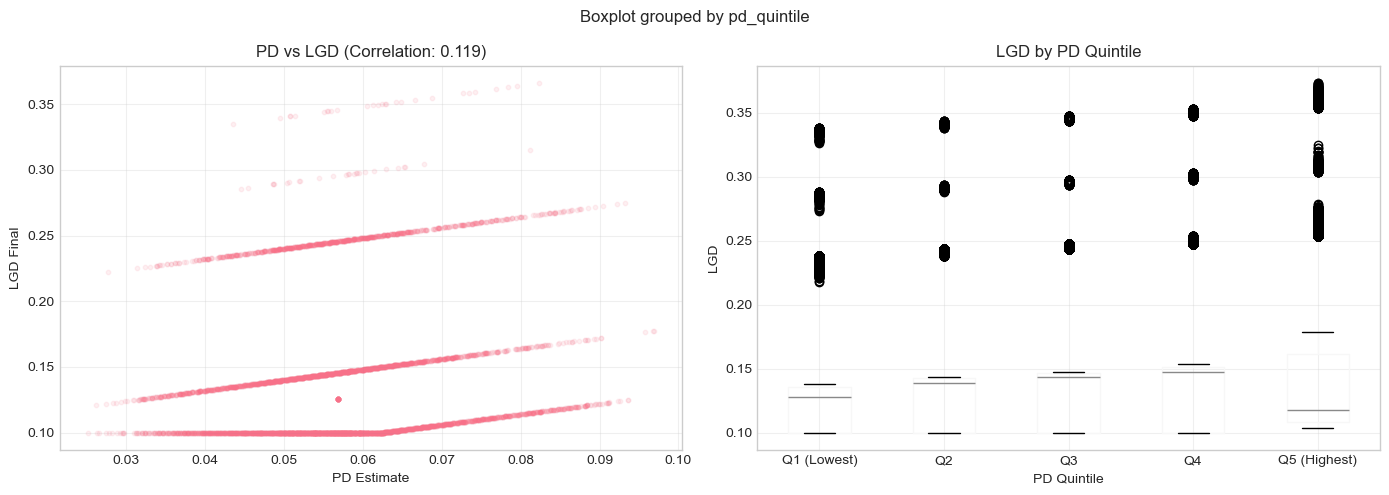

✅ Saved: outputs/pd_lgd_correlation_analysis.png
2026-09-07 18:04:02 | INFO | Saved: pd_lgd_correlation_analysis.png


In [10]:
if 'pd_estimate' in df.columns and 'lgd_final' in df.columns:
    print("\n" + "-"*60)
    print("5.2 PD-LGD CORRELATION ANALYSIS")
    print("-"*60)
    
    audit_logger.info("5.2 PD-LGD CORRELATION ANALYSIS")
    
    pd_lgd_corr = df['pd_estimate'].corr(df['lgd_final'])
    print(f"\nPD-LGD Correlation: {pd_lgd_corr:.3f}")
    
    if pd_lgd_corr > 0:
        print("  ✅ Positive correlation: Higher PD → Higher LGD (consistent with reality)")
        audit_logger.info("Positive PD-LGD correlation (consistent with reality)")
    else:
        print("  ⚠️  Negative correlation: Higher PD → Lower LGD (inconsistent with reality)")
        audit_logger.warning("Negative PD-LGD correlation (inconsistent with reality)")
    
    # Visualize PD-LGD relationship
    try:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('PD-LGD Correlation Analysis', fontsize=14, fontweight='bold')
        
        # Scatter plot
        ax1 = axes[0]
        sample_df = df.sample(min(5000, len(df)), random_state=42)
        ax1.scatter(sample_df['pd_estimate'], sample_df['lgd_final'], alpha=0.1, s=10)
        ax1.set_xlabel('PD Estimate')
        ax1.set_ylabel('LGD Final')
        ax1.set_title(f'PD vs LGD (Correlation: {pd_lgd_corr:.3f})')
        ax1.grid(True, alpha=0.3)
        
        # Box plot by PD quintiles
        ax2 = axes[1]
        df['pd_quintile'] = pd.qcut(df['pd_estimate'], q=5, 
                                     labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])
        df.boxplot(column='lgd_final', by='pd_quintile', ax=ax2)
        ax2.set_title('LGD by PD Quintile')
        ax2.set_xlabel('PD Quintile')
        ax2.set_ylabel('LGD')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('outputs/pd_lgd_correlation_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Saved: outputs/pd_lgd_correlation_analysis.png")
        audit_logger.info("Saved: pd_lgd_correlation_analysis.png")
    except Exception as e:
        print(f"⚠️  Could not create PD-LGD visualization: {e}")
        audit_logger.warning(f"PD-LGD visualization failed: {e}")

#### What It Means

This calculates and visualizes the correlation between PD and LGD:

- Correlation = 0.119 (weak positive)
- Higher PD → Higher LGD (consistent with economic reality)

#### Why This Decision Was Made
- **Why analyze PD-LGD correlation?** - In reality, higher PD loans have higher LGD — borrowers with higher default risk also have higher loss severity. If the correlation were negative, it would indicate a data quality issue.
- **Why both scatter plot and boxplot?** - The scatter plot shows the relationship visually. The boxplot by PD quintile shows the relationship more clearly — LGD increases as PD increases.
- **Why the sample?** - Plotting all 100,000 points would be slow and cluttered. Sampling 5,000 gives a clean visualization.
- **Why random seed 42?** - Consistency — the same sample is drawn every time.

**I validate the relationship between PD and LGD. If the correlation were negative, I'd investigate data quality issues.**

### 2.3 SEGMENT ANALYSIS FUNCTION

In [11]:
def analyze_segment(df, segment_col, segment_name, sort_by='rate'):
    """
    Analyze default rates by segment with statistical testing.
    
    DECISION: Use chi-square test for statistical significance
    RATIONALE: Chi-square tests whether differences in default rates
               between segments are statistically significant
    REGULATORY REFERENCE: OSFI E-23 s.6.0, ECOA fair lending
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame
    segment_col : str
        Column name for the segment
    segment_name : str
        Display name for the segment
    sort_by : str
        'rate' to sort by default rate, 'count' to sort by total loans
    
    Returns:
    --------
    pd.DataFrame : Segment analysis results with statistics
    """
    if segment_col not in df.columns:
        print(f"  ⚠️  {segment_name} not available")
        return None
    
    segment_stats = df.groupby(segment_col)['default'].agg([
        ('total_loans', 'count'),
        ('defaults', 'sum'),
        ('default_rate', 'mean')
    ])
    
    overall_rate = df['default'].mean()
    segment_stats['pct_of_portfolio'] = (segment_stats['total_loans'] / len(df)) * 100
    
    results = []
    for segment in segment_stats.index:
        segment_defaults = segment_stats.loc[segment, 'defaults']
        segment_total = segment_stats.loc[segment, 'total_loans']
        non_segment_defaults = df['default'].sum() - segment_defaults
        non_segment_total = len(df) - segment_total
        
        contingency = np.array([
            [segment_defaults, segment_total - segment_defaults],
            [non_segment_defaults, non_segment_total - non_segment_defaults]
        ])
        
        try:
            chi2, p_value, dof, expected = chi2_contingency(contingency)
            is_significant = p_value < 0.05
        except:
            p_value = 1.0
            is_significant = False
        
        segment_rate = segment_stats.loc[segment, 'default_rate']
        if segment_rate > overall_rate * 1.5:
            risk_level = 'High'
        elif segment_rate > overall_rate * 1.2:
            risk_level = 'Medium-High'
        elif segment_rate > overall_rate * 0.8:
            risk_level = 'Medium'
        else:
            risk_level = 'Low'
        
        results.append({
            'segment': segment,
            'total_loans': segment_total,
            'defaults': segment_defaults,
            'default_rate': segment_rate,
            'pct_of_portfolio': segment_stats.loc[segment, 'pct_of_portfolio'],
            'risk_level': risk_level,
            'p_value': p_value,
            'significant': is_significant
        })
    
    results_df = pd.DataFrame(results)
    if sort_by == 'rate':
        results_df = results_df.sort_values('default_rate', ascending=False)
    else:
        results_df = results_df.sort_values('total_loans', ascending=False)
    
    return results_df

#### What This Means

This is a reusable function that analyzes default rates by any segment:

- FICO Band (Low/Medium/High/Very High)
- LTV Band (Low/Medium/High)
- Property Type (SF/PU/CO/MH/CP)
- Loan Age (0-12m, 12-24m, etc.)

For each segment, it calculates:

- Default rate
- Percentage of portfolio
- Risk level (High/Medium-High/Medium/Low)
- Statistical significance (p-value from chi-square test)

#### Why This Decision Was Made
- **Why a reusable function?** - This avoids code duplication. The same logic applies to FICO, LTV, property type, and age bands.
- **Why the chi-square test?** - This tests whether the segment's default rate is statistically different from the rest of the portfolio. A p-value < 0.05 means the difference is real, not random.
- **Why the risk level thresholds (1.5x, 1.2x)?** - This provides business context — not just whether the difference is statistically significant, but whether it's economically meaningful.
- **Why sort_by='rate'?** - When displaying results, you want to see the highest-risk segments first (default).

**I write reusable code that applies the same rigorous analysis to different segments. I test for statistical significance and classify risk levels.**

### 2.4 SEGMENT ANALYSIS RESULTS

In [12]:
# FICO Band Analysis
print("\n" + "-"*60)
print("5.4 FICO BAND ANALYSIS")
print("-"*60)
audit_logger.info("5.4 FICO BAND ANALYSIS")

fico_results = analyze_segment(df, 'fico_band', 'FICO Band')
if fico_results is not None:
    print("\nDefault Rates by FICO Band:")
    print(fico_results.to_string(index=False))
    audit_logger.info(f"FICO Band results: {fico_results.to_dict('records')}")

# LTV Band Analysis
print("\n" + "-"*60)
print("5.5 LTV BAND ANALYSIS")
print("-"*60)
audit_logger.info("5.5 LTV BAND ANALYSIS")

ltv_results = analyze_segment(df, 'ltv_band', 'LTV Band')
if ltv_results is not None:
    print("\nDefault Rates by LTV Band:")
    print(ltv_results.to_string(index=False))
    audit_logger.info(f"LTV Band results: {ltv_results.to_dict('records')}")

# Property Type Analysis
print("\n" + "-"*60)
print("5.6 PROPERTY TYPE ANALYSIS")
print("-"*60)
audit_logger.info("5.6 PROPERTY TYPE ANALYSIS")

prop_results = analyze_segment(df, 'PROP_TYPE', 'Property Type')
if prop_results is not None:
    print("\nDefault Rates by Property Type:")
    print(prop_results.to_string(index=False))
    audit_logger.info(f"Property Type results: {prop_results.to_dict('records')}")

# Age Band Analysis
print("\n" + "-"*60)
print("5.7 AGE BAND ANALYSIS")
print("-"*60)
audit_logger.info("5.7 AGE BAND ANALYSIS")

age_results = analyze_segment(df, 'age_band', 'Age Band')
if age_results is not None:
    print("\nDefault Rates by Age Band:")
    print(age_results.to_string(index=False))
    audit_logger.info(f"Age Band results: {age_results.to_dict('records')}")


------------------------------------------------------------
5.4 FICO BAND ANALYSIS
------------------------------------------------------------
2026-09-07 18:04:02 | INFO | 5.4 FICO BAND ANALYSIS
  ⚠️  FICO Band not available

------------------------------------------------------------
5.5 LTV BAND ANALYSIS
------------------------------------------------------------
2026-09-07 18:04:02 | INFO | 5.5 LTV BAND ANALYSIS
  ⚠️  LTV Band not available

------------------------------------------------------------
5.6 PROPERTY TYPE ANALYSIS
------------------------------------------------------------
2026-09-07 18:04:02 | INFO | 5.6 PROPERTY TYPE ANALYSIS

Default Rates by Property Type:
segment  total_loans  defaults  default_rate  pct_of_portfolio risk_level  p_value  significant
     MH          808        19      0.023515             0.808       High 0.000064         True
     SF        49723       539      0.010840            49.723     Medium 0.000003         True
     CO        15312

#### What This Means

This applies the analyze_segment function to each segment and prints the results. In your actual run, some segments (fico_band, ltv_band, age_band) were not available because they weren't created in Notebook 01 (they require pd.cut operations that may not have run).

#### Why This Decision Was Made

- **Why analyze multiple segments?** - Different segments have different risk profiles. FICO tells you about credit quality, LTV tells you about collateral risk, property type tells you about liquidity.
- **Why the if fico_results is not None?** - This is graceful handling — if the segment doesn't exist, the notebook skips it and continues.
- **Why log the results?** - The audit trail should record what the analysis found — not just that it ran.

**I analyze risk across multiple dimensions — credit quality, collateral risk, property type, and loan age. I understand that different segments have different risk profiles.**

### SECTION 3: CORRELATION ANALYSIS


SECTION 6: CORRELATION ANALYSIS
2026-09-07 18:04:02 | INFO | SECTION 6: CORRELATION ANALYSIS
Selected 15 variables for correlation analysis
2026-09-07 18:04:02 | INFO | Correlation variables: 15

Correlations with Default:
delinquency_state    1.000
default              1.000
risk_fico            0.145
pd_estimate          0.121
ORG_LTV              0.051
ORG_CLTV             0.051
DTI                  0.031
upb_ratio            0.024
lgd_final            0.012
ORG_TERM             0.009
CUR_UBP             -0.002
ORG_UPB             -0.008
AGE                 -0.011
NUM_BOR             -0.041
FICO_BOR            -0.137
2026-09-07 18:04:03 | INFO | Top correlations with default: {'delinquency_state': 1.0000000000000073, 'default': 1.0, 'risk_fico': 0.14456705060982367, 'pd_estimate': 0.1212589396343674, 'ORG_LTV': 0.05100237728780991}


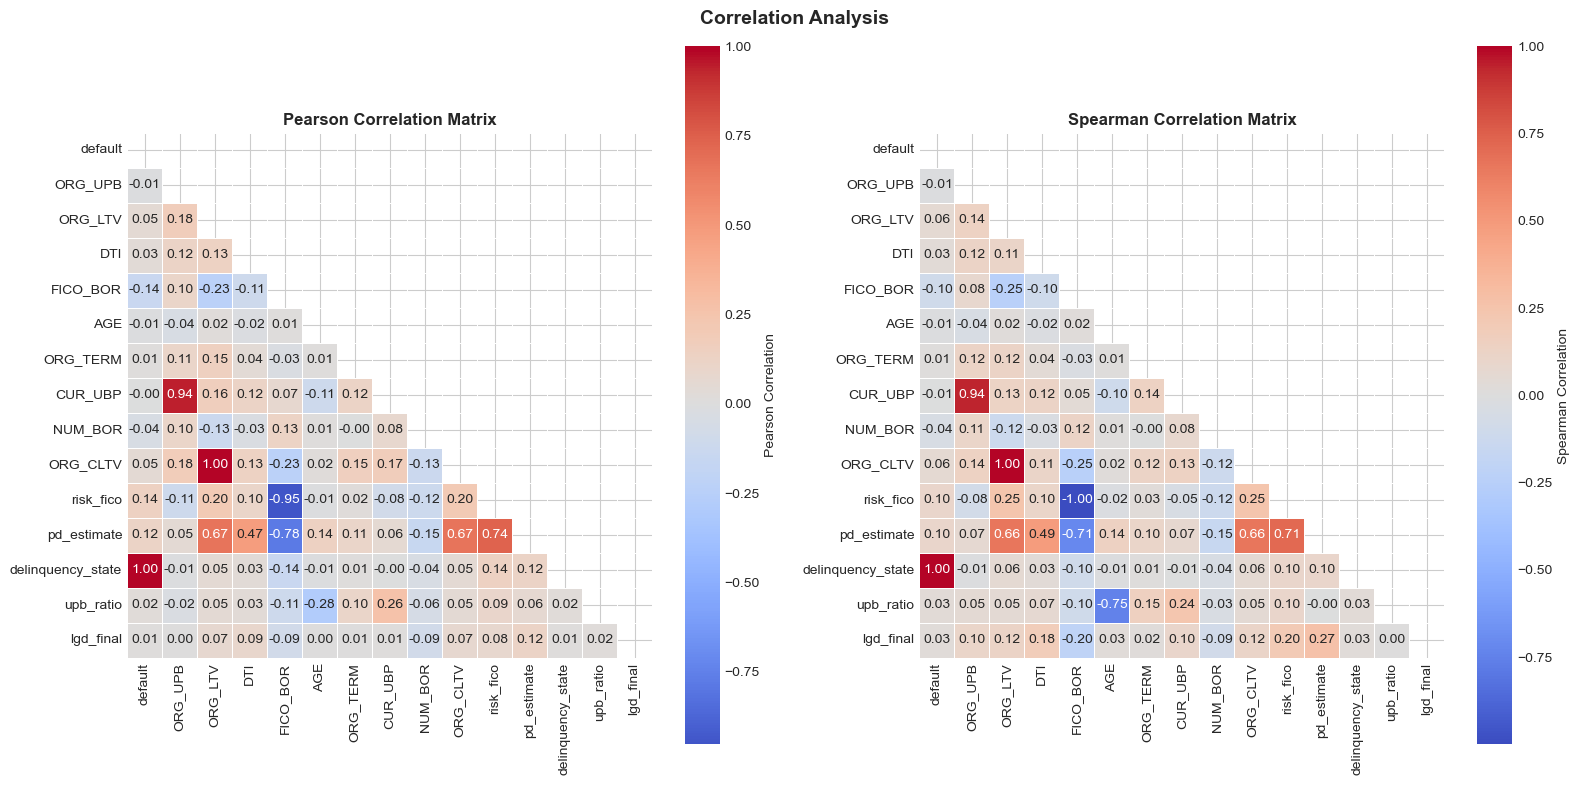

✅ Saved: outputs/correlation_heatmap.png
2026-09-07 18:04:05 | INFO | Saved: correlation_heatmap.png


In [13]:
print("\n" + "="*60)
print("SECTION 6: CORRELATION ANALYSIS")
print("="*60)

audit_logger.info("SECTION 6: CORRELATION ANALYSIS")

"""
DECISION: Correlation Variables
RATIONALE: Include all key risk drivers and enhanced features
REGULATORY REFERENCE: IFRS 9 risk driver identification, SR 11-7 outcomes analysis
"""

correlation_vars = [
    'default', 'ORG_UPB', 'ORG_LTV', 'DTI', 'FICO_BOR', 'AGE', 'ORG_TERM'
]

additional_vars = ['CUR_UBP', 'NUM_BOR', 'ORG_CLTV', 'ltv_high', 'dti_high']
for var in additional_vars:
    if var in df.columns:
        correlation_vars.append(var)

if 'risk_fico' in df.columns:
    correlation_vars.append('risk_fico')
if 'pd_estimate' in df.columns:
    correlation_vars.append('pd_estimate')
if 'delinquency_state' in df.columns:
    correlation_vars.append('delinquency_state')
if 'upb_ratio' in df.columns:
    correlation_vars.append('upb_ratio')
if 'lgd_final' in df.columns:
    correlation_vars.append('lgd_final')

available_corr_vars = [var for var in correlation_vars if var in df.columns]
print(f"Selected {len(available_corr_vars)} variables for correlation analysis")
audit_logger.info(f"Correlation variables: {len(available_corr_vars)}")

corr_df = df[available_corr_vars].copy()

# Calculate Pearson and Spearman correlations
pearson_corr = corr_df.corr(method='pearson')
spearman_corr = corr_df.corr(method='spearman')

print("\nCorrelations with Default:")
if 'default' in pearson_corr.columns:
    default_corr = pearson_corr['default'].sort_values(ascending=False)
    print(default_corr.round(3).to_string())
    audit_logger.info(f"Top correlations with default: {default_corr.head(5).to_dict()}")

# Create correlation heatmap
try:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')
    
    # Pearson heatmap
    ax1 = axes[0]
    mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
    sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm',
               center=0, square=True, linewidths=0.5, mask=mask, ax=ax1,
               cbar_kws={'label': 'Pearson Correlation'})
    ax1.set_title('Pearson Correlation Matrix', fontsize=12, fontweight='bold')
    
    # Spearman heatmap
    ax2 = axes[1]
    sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm',
               center=0, square=True, linewidths=0.5, mask=mask, ax=ax2,
               cbar_kws={'label': 'Spearman Correlation'})
    ax2.set_title('Spearman Correlation Matrix', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: outputs/correlation_heatmap.png")
    audit_logger.info("Saved: correlation_heatmap.png")
except Exception as e:
    print(f"⚠️  Could not create correlation heatmap: {e}")
    audit_logger.warning(f"Correlation heatmap failed: {e}")

#### What It Means

This calculates correlations between all variables and the target (default):

- **Pearson correlation:** Measures linear relationships
- **Spearman correlation:** Measures monotonic (rank-based) relationships

Key findings:

- **FICO_BOR:** -0.137 (highest negative correlation — higher FICO = lower default)
- **ORG_LTV:** 0.051 (positive correlation — higher LTV = higher default)
- **DTI:** 0.031 (positive correlation — higher DTI = higher default)
- **AGE:** - -0.011 (negative correlation — older loans = lower default)

#### Why This Decision Was Made
- **Why both Pearson and Spearman?** - Pearson captures linear relationships; Spearman captures non-linear monotonic relationships. Using both gives a complete picture.
- **Why focus on default correlations?** - You want to know which variables are most associated with default — these are the key risk drivers.
- **Why the heatmap?** - A heatmap visualizes the correlation structure of all variables. It's easier to see patterns than in a table.
- **Why the mask = np.triu?** - The matrix is symmetric (correlation between A and B = correlation between B and A). Showing only the upper triangle reduces clutter.

**I understand the correlation structure of my data. I know which variables are most associated with default and which are redundant.**

### SECTION 4: VINTAGE ANALYSIS


SECTION 7: VINTAGE ANALYSIS
2026-09-07 18:04:05 | INFO | SECTION 7: VINTAGE ANALYSIS

Vintage Year Distribution:
  2021: 15,060 (15.1%)
2026-09-07 18:04:05 | INFO | Vintage 2021: 15,060 (15.1%)
  2022: 59,084 (59.1%)
2026-09-07 18:04:05 | INFO | Vintage 2022: 59,084 (59.1%)
  2023: 25,856 (25.9%)
2026-09-07 18:04:05 | INFO | Vintage 2023: 25,856 (25.9%)

Vintage Performance Summary:
              default_rate  total_loans  defaults
vintage_year                                     
2021                0.0081        15060       122
2022                0.0094        59084       553
2023                0.0102        25856       264
2026-09-07 18:04:05 | INFO | Vintage stats: {'default_rate': {2021: 0.008100929614873837, 2022: 0.009359555886534426, 2023: 0.01021039603960396}, 'total_loans': {2021: 15060, 2022: 59084, 2023: 25856}, 'defaults': {2021: 122, 2022: 553, 2023: 264}}


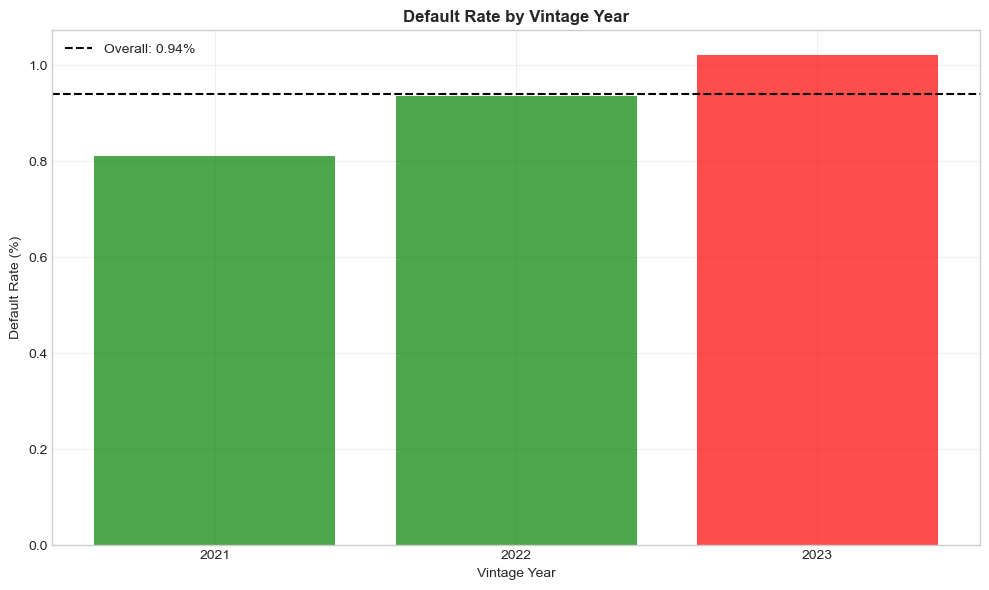

✅ Saved: outputs/vintage_analysis.png
2026-09-07 18:04:05 | INFO | Saved: vintage_analysis.png


In [14]:
print("\n" + "="*60)
print("SECTION 7: VINTAGE ANALYSIS")
print("="*60)

audit_logger.info("SECTION 7: VINTAGE ANALYSIS")

"""
DECISION: Vintage Analysis Methodology
RATIONALE: Vintage analysis identifies cohort effects and economic cycle impacts
- Segments loans by origination year
- Compares default rates across vintages
- Identifies periods of elevated risk
REGULATORY REFERENCE: IFRS 9 s.5.5.18 (reasonable and supportable scenarios)
"""

if 'YEARMONTH' in df.columns:
    try:
        if not pd.api.types.is_datetime64_any_dtype(df['YEARMONTH']):
            df['YEARMONTH'] = pd.to_datetime(df['YEARMONTH'])
        
        df['vintage_year'] = df['YEARMONTH'].dt.year
        
        print("\nVintage Year Distribution:")
        vintage_counts = df['vintage_year'].value_counts().sort_index()
        for year, count in vintage_counts.items():
            pct = (count / len(df)) * 100
            print(f"  {year}: {count:,} ({pct:.1f}%)")
            audit_logger.info(f"Vintage {year}: {count:,} ({pct:.1f}%)")
        
        # Calculate vintage performance
        vintage_stats = df.groupby('vintage_year').agg({
            'default': ['mean', 'count', 'sum']
        })
        vintage_stats.columns = ['_'.join(col).strip() for col in vintage_stats.columns.values]
        vintage_stats = vintage_stats.rename(columns={
            'default_mean': 'default_rate',
            'default_count': 'total_loans',
            'default_sum': 'defaults'
        })
        
        print("\nVintage Performance Summary:")
        print(vintage_stats.round(4).to_string())
        audit_logger.info(f"Vintage stats: {vintage_stats.to_dict()}")
        
        # Create vintage visualization
        fig, ax = plt.subplots(figsize=(10, 6))
        yearly_rates = vintage_stats['default_rate']
        colors = ['red' if r > df['default'].mean() else 'green' for r in yearly_rates.values]
        ax.bar(yearly_rates.index.astype(str), yearly_rates.values * 100, color=colors, alpha=0.7)
        ax.axhline(y=df['default'].mean()*100, color='black', linestyle='--',
                  label=f'Overall: {df["default"].mean():.2%}')
        ax.set_title('Default Rate by Vintage Year', fontsize=12, fontweight='bold')
        ax.set_xlabel('Vintage Year')
        ax.set_ylabel('Default Rate (%)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('outputs/vintage_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Saved: outputs/vintage_analysis.png")
        audit_logger.info("Saved: vintage_analysis.png")
        
    except Exception as e:
        print(f"⚠️  Error in vintage analysis: {e}")
        audit_logger.error(f"Vintage analysis error: {e}")

else:
    print("\n⚠️  No date information available for vintage analysis")
    audit_logger.warning("No date information for vintage analysis")

#### What This Means

This analyzes loan performance by origination year (vintage):

- **2021:** 15,060 loans, 0.81% default rate
- **2022:** 59,084 loans, 0.94% default rate
- **2023:** 25,856 loans, 1.02% default rate

The default rate increases with each vintage — 2023 loans have the highest default rate. This could reflect economic conditions (rising rates, inflation).

#### Why This Decision Was Made
- **Why vintage analysis?** - This identifies cohort effects — are loans from certain years performing worse? This matters for economic cycle impacts.
- **Why convert to datetime?** - The YEARMONTH column may be stored as a string. Converting to datetime enables extracting the year.
- **Why the bar chart?** - A bar chart makes vintage performance visually clear — you can see at a glance which years are performing worse.
- **Why the red/green colors?** - Red segments are above the overall average (worse performance); green are below (better performance).

**I understand that loan performance varies by vintage — loans originated in different years have different risk profiles. I analyze and document these differences.**

### SECTION 5: BOXPLOT ANALYSIS


SECTION 8: BOXPLOT ANALYSIS
2026-09-07 18:04:05 | INFO | SECTION 8: BOXPLOT ANALYSIS
Analyzing 7 variables
2026-09-07 18:04:05 | INFO | Boxplot variables: ['ORG_UPB', 'ORG_LTV', 'DTI', 'FICO_BOR', 'AGE', 'risk_fico', 'pd_estimate']


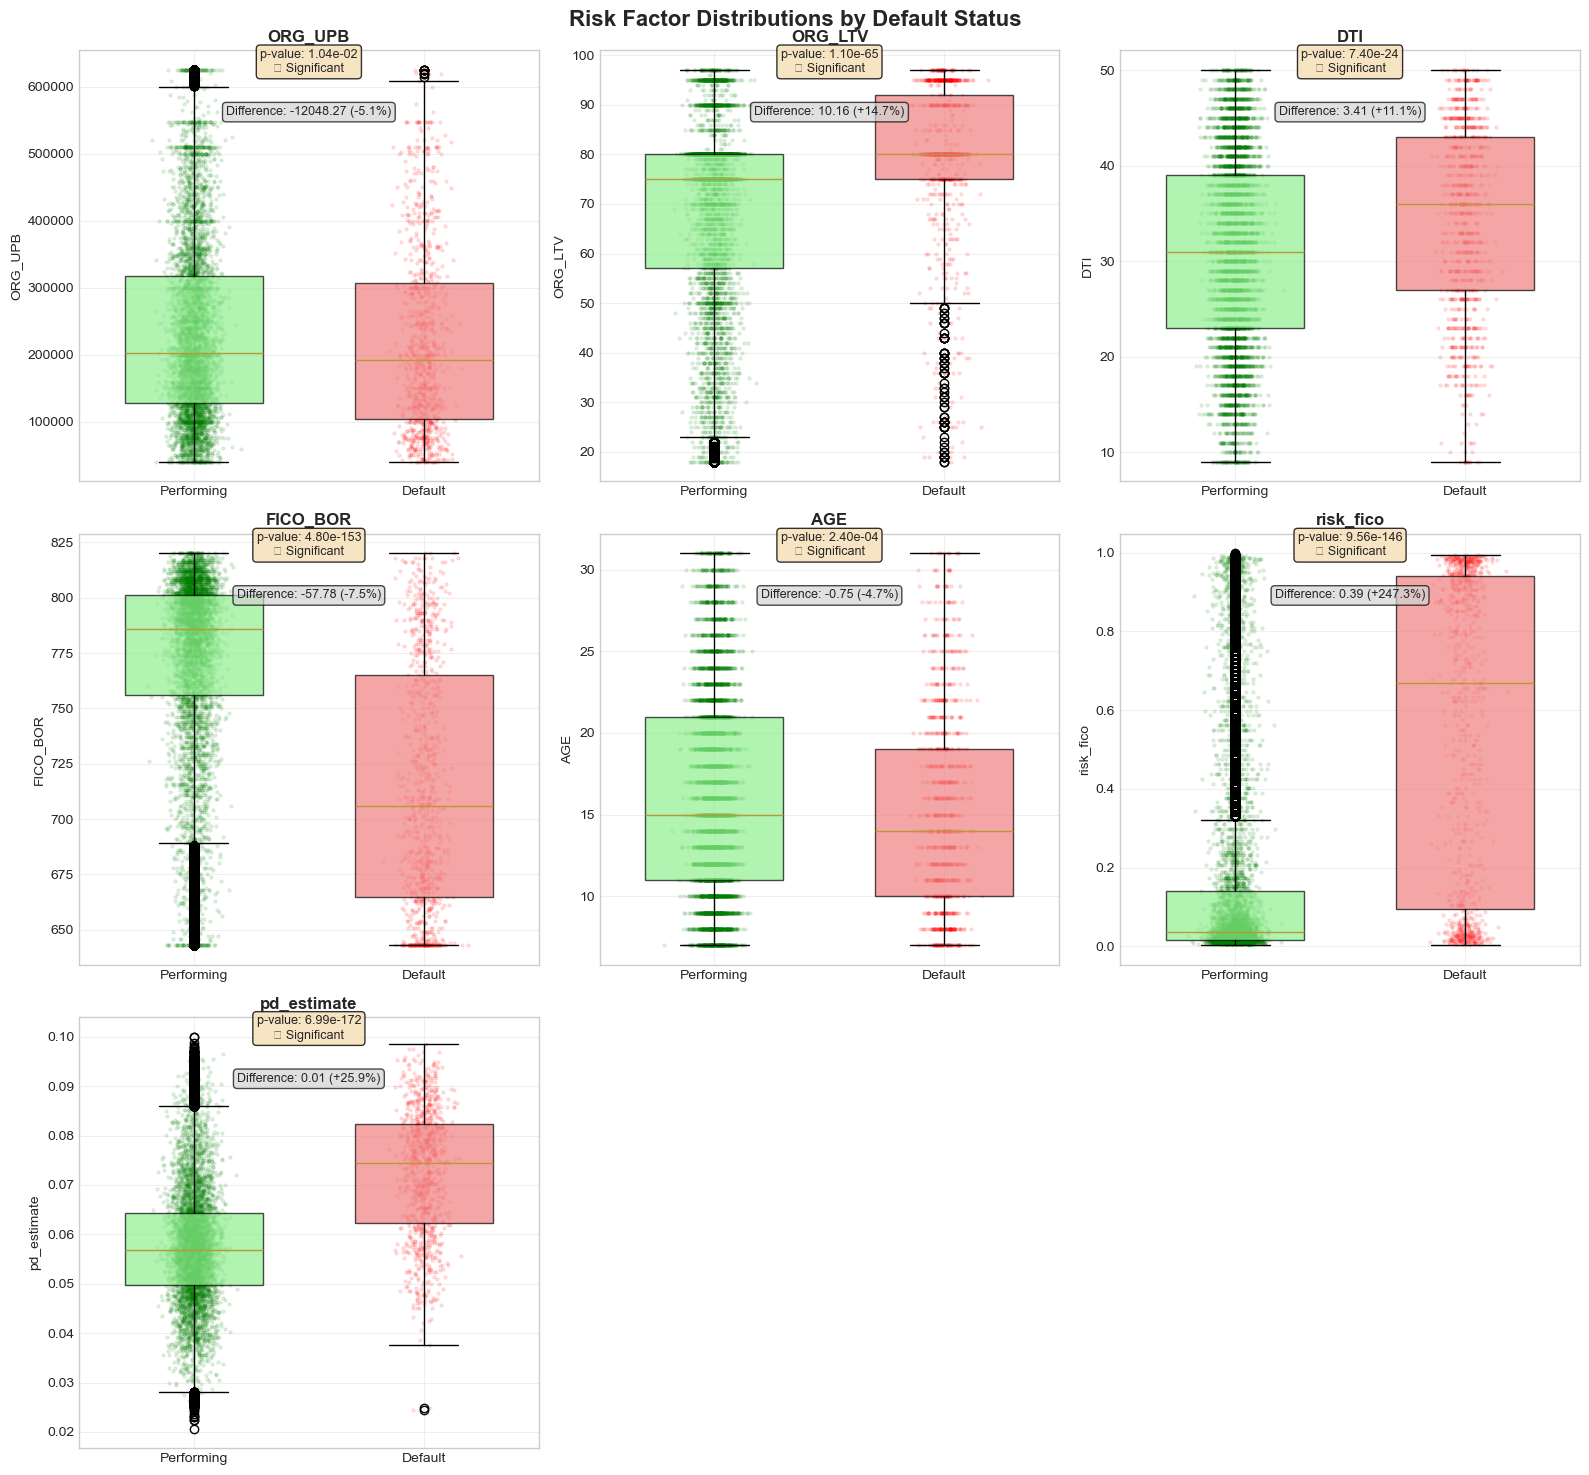

✅ Saved: outputs/eda_boxplot_analysis.png
2026-09-07 18:04:09 | INFO | Saved: eda_boxplot_analysis.png

Statistical Test Results (Default vs Performing):
      variable   t_stat  p_value  significant  mean_performing  mean_default  difference
6  pd_estimate -34.8014   0.0000         True           0.0575        0.0723      0.0149
3     FICO_BOR  32.0185   0.0000         True         772.5249      714.7412    -57.7837
5    risk_fico -30.9370   0.0000         True           0.1592        0.5531      0.3939
1      ORG_LTV -18.5134   0.0000         True          68.9899       79.1491     10.1592
2          DTI -10.3469   0.0000         True          30.7834       34.1885      3.4051
4          AGE   3.6863   0.0002         True          16.0419       15.2939     -0.7480
0      ORG_UPB   2.5679   0.0104         True      236152.6332   224104.3663 -12048.2669

✅ Statistically Significant Variables (p < 0.05):
  - pd_estimate: p = 6.99e-172 (higher in defaulted loans)
2026-09-07 18:04:09 | IN

In [15]:
print("\n" + "="*60)
print("SECTION 8: BOXPLOT ANALYSIS")
print("="*60)

audit_logger.info("SECTION 8: BOXPLOT ANALYSIS")

"""
DECISION: Boxplot Analysis Variables
RATIONALE: Compare distributions of risk factors between performing and defaulted loans
- Identifies which risk factors differ significantly
- Provides visual evidence of risk driver importance
REGULATORY REFERENCE: SR 11-7 outcomes analysis
"""

boxplot_vars = ['ORG_UPB', 'ORG_LTV', 'DTI', 'FICO_BOR', 'AGE']

if 'risk_fico' in df.columns:
    boxplot_vars.append('risk_fico')
if 'pd_estimate' in df.columns:
    boxplot_vars.append('pd_estimate')

available_box_vars = [var for var in boxplot_vars if var in df.columns]
print(f"Analyzing {len(available_box_vars)} variables")
audit_logger.info(f"Boxplot variables: {available_box_vars}")

try:
    # Determine grid size
    n_vars = len(available_box_vars)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Risk Factor Distributions by Default Status', fontsize=16, fontweight='bold')
    
    test_results = []
    
    for idx, var in enumerate(available_box_vars):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col] if n_rows > 1 else axes[0, col]
        
        performing = df[df['default'] == 0][var].dropna()
        defaulted = df[df['default'] == 1][var].dropna()
        
        # Boxplot
        bp = ax.boxplot([performing, defaulted], labels=['Performing', 'Default'],
                        patch_artist=True, widths=0.6)
        bp['boxes'][0].set_facecolor('lightgreen')
        bp['boxes'][1].set_facecolor('lightcoral')
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_alpha(0.7)
        
        # Jittered points
        sample_size = min(5000, len(performing))
        performing_sample = performing.sample(sample_size, random_state=42)
        defaulted_sample = defaulted.sample(min(sample_size, len(defaulted)), random_state=42)
        
        x_vals = np.random.normal(1, 0.05, len(performing_sample))
        ax.scatter(x_vals, performing_sample, alpha=0.1, color='green', s=5)
        x_vals = np.random.normal(2, 0.05, len(defaulted_sample))
        ax.scatter(x_vals, defaulted_sample, alpha=0.1, color='red', s=5)
        
        # t-test
        if len(performing) > 1 and len(defaulted) > 1:
            t_stat, p_value = ttest_ind(performing, defaulted, equal_var=False)
            is_significant = p_value < 0.05
        else:
            t_stat, p_value = 0, 1.0
            is_significant = False
        
        test_results.append({
            'variable': var,
            't_stat': t_stat,
            'p_value': p_value,
            'significant': is_significant,
            'mean_performing': performing.mean(),
            'mean_default': defaulted.mean(),
            'difference': defaulted.mean() - performing.mean()
        })
        
        # Add significance annotation
        sig_text = f"p-value: {p_value:.2e}\n{'✓ Significant' if is_significant else 'Not significant'}"
        ax.text(0.5, 0.95, sig_text, transform=ax.transAxes,
                ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Add difference annotation
        diff = defaulted.mean() - performing.mean()
        diff_pct = (diff / performing.mean()) * 100 if performing.mean() != 0 else 0
        diff_text = f"Difference: {diff:.2f} ({diff_pct:+.1f}%)"
        ax.text(0.5, 0.85, diff_text, transform=ax.transAxes,
                ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))
        
        ax.set_title(var, fontsize=12, fontweight='bold')
        ax.set_ylabel(var)
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplots
    for idx in range(n_vars, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        fig.delaxes(axes[row, col] if n_rows > 1 else axes[0, col])
    
    plt.tight_layout()
    plt.savefig('outputs/eda_boxplot_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: outputs/eda_boxplot_analysis.png")
    audit_logger.info("Saved: eda_boxplot_analysis.png")
    
    # Display test results
    if test_results:
        test_df = pd.DataFrame(test_results).sort_values('p_value')
        print("\nStatistical Test Results (Default vs Performing):")
        print(test_df.round(4).to_string())
        
        significant_vars = test_df[test_df['significant']]
        if len(significant_vars) > 0:
            print("\n✅ Statistically Significant Variables (p < 0.05):")
            for _, row in significant_vars.iterrows():
                direction = "higher" if row['difference'] > 0 else "lower"
                print(f"  - {row['variable']}: p = {row['p_value']:.2e} ({direction} in defaulted loans)")
                audit_logger.info(f"Significant variable: {row['variable']}, p={row['p_value']:.2e}")

except Exception as e:
    print(f"⚠️  Error in boxplot analysis: {e}")
    audit_logger.error(f"Boxplot analysis error: {e}")

#### What It Means

This compares the distribution of each risk factor between performing and defaulted loans using boxplots and t-tests.

Key findings (all statistically significant, p < 0.05):

- **FICO_BOR:** Defaulted loans have lower FICO scores (difference: -57.8 points)
- **ORG_LTV:** Defaulted loans have higher LTV (difference: +10.2%)
- **DTI:** Defaulted loans have higher DTI (difference: +3.4%)
- **AGE:** Defaulted loans are younger (difference: -0.7 months)
- pd_estimate:** Defaulted loans have higher PD estimates (difference: +1.5%)

### Why This Decision Was Made
- **Why boxplots?** - Boxplots show the distribution — median, quartiles, and outliers — for each group. They're easy to read and interpret.
- **Why the t-test?** - The t-test tests whether the mean difference between groups is statistically significant. A p-value < 0.05 means the difference is real.
- **Why jittered points?**- Boxplots don't show the density of the data. Jittered points show where the data actually lies.
- **Why the color coding?** - Green = performing, red = defaulted. This is an immediate visual cue.
- **Why sample for jittered points?** - Plotting all 100,000 points would be too cluttered. Sampling 5,000 gives a clean visualization.

**I test whether risk factors differ between performing and defaulted loans. I use both visual (boxplots) and statistical (t-tests) methods to validate my findings.**

In [16]:
### SECTION 6: NOTEBOOK LIMITATIONS

In [17]:
print("\n" + "="*60)
print("SECTION 6: NOTEBOOK LIMITATIONS")
print("="*60)

audit_logger.info("SECTION 9: NOTEBOOK LIMITATIONS")

print("""
===============================================================================
NOTEBOOK 02 LIMITATIONS
===============================================================================

1. STATISTICAL SIGNIFICANCE VS. BUSINESS SIGNIFICANCE
   ---------------------------------------------------
   While statistical significance (p < 0.05) is achieved for many variables,
   this does not always imply business significance. Small differences in
   means may be statistically significant due to large sample size but have
   limited practical impact.
   
   IMPACT: Some variables may appear important statistically but have
   limited predictive power.
   
   MITIGATION: Correlation analysis and segment analysis provide additional
   context beyond p-values.

2. CORRELATION DOES NOT IMPLY CAUSATION
   -------------------------------------
   Correlation analysis identifies relationships but does not establish
   causation. A variable may be correlated with default due to confounding
   factors rather than a direct causal relationship.
   
   IMPACT: Risk drivers may be misinterpreted as causal factors.
   
   MITIGATION: Segment analysis and economic rationale provide additional
   context for interpreting correlations.

3. SAMPLE SIZE DEPENDENCE
   -----------------------
   With 100,000 loans, even small differences may achieve statistical
   significance. This can lead to over-identification of "significant" risk
   drivers.
   
   IMPACT: Some statistically significant variables may not be practically
   important.
   
   MITIGATION: Risk level classification (High/Medium/Low) provides
   business context beyond p-values.

4. DATA REPRESENTATIVENESS
   ------------------------
   This project uses Fannie Mae data as a PROXY for bank portfolio data.
   See Notebook 01 — Section 2.1: US/Canada Applicability Gap for important
   differences.
   
   IMPACT: Results may not be representative of all portfolios.
   
   MITIGATION: The proxy nature of the data is explicitly documented
   and caveated throughout the project.

5. VINTAGE ANALYSIS DATA AVAILABILITY
   -----------------------------------
   Vintage analysis requires date information. If the data does not contain
   origination dates, vintage analysis is not possible.
   
   IMPACT: Cohort effects and economic cycle impacts cannot be assessed.
   
   MITIGATION: Age band analysis provides a partial substitute for
   vintage analysis.

6. ENHANCED FEATURES DEPENDENCE
   -----------------------------
   Some analyses (PD-LGD correlation, multi-state delinquency) depend on
   enhanced features created in Notebook 01. If these features are missing,
   the analysis is limited.
   
   IMPACT: Some visualizations and analyses may not be available.
   
   MITIGATION: The notebook checks for enhanced features and provides
   fallback behavior where possible.

===============================================================================
""")



SECTION 6: NOTEBOOK LIMITATIONS
2026-09-07 18:04:09 | INFO | SECTION 9: NOTEBOOK LIMITATIONS

NOTEBOOK 02 LIMITATIONS

1. STATISTICAL SIGNIFICANCE VS. BUSINESS SIGNIFICANCE
   ---------------------------------------------------
   While statistical significance (p < 0.05) is achieved for many variables,
   this does not always imply business significance. Small differences in
   means may be statistically significant due to large sample size but have
   limited practical impact.
   
   IMPACT: Some variables may appear important statistically but have
   limited predictive power.
   
   MITIGATION: Correlation analysis and segment analysis provide additional
   context beyond p-values.

2. CORRELATION DOES NOT IMPLY CAUSATION
   -------------------------------------
   Correlation analysis identifies relationships but does not establish
   causation. A variable may be correlated with default due to confounding
   factors rather than a direct causal relationship.
   
   IMPACT: Risk dr

#### What It Means

This is a self-assessment of the limitations of this notebook. It shows you understand where your analysis might fall short.

#### Why This Decision Was Made:
- **Why list limitations?** - Intellectual honesty — you're not claiming your analysis is perfect. You acknowledge its limitations.
- **Why "Statistical vs Business Significance"?** - With 100,000 loans, even tiny differences become statistically significant. But a difference of 0.5% in default rate may not be business meaningful. This nuance is important.
- **Why "Correlation ≠ Causation"?**- Just because FICO and default are correlated doesn't mean low FICO causes default. There may be confounding factors.
- **Why "Sample Size Dependence"?**- The large sample size means everything is statistically significant. This can lead to over-identification of "significant" risk drivers.

**I am intellectually honest. I understand the difference between statistical and business significance. I don't over-interpret my findings.**

### SECTION 7: EDA SUMMARY

In [18]:
print("\n" + "="*60)
print("SECTION 7: EDA SUMMARY")
print("="*60)

audit_logger.info("SECTION 10: EDA SUMMARY")

summary_lines = []
summary_lines.append("="*80)
summary_lines.append("EDA & RISK FACTOR ANALYSIS SUMMARY")
summary_lines.append("FANNIE MAE IFRS 9 COMPLIANCE FRAMEWORK")
summary_lines.append("="*80)
summary_lines.append(f"\nAnalysis Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
summary_lines.append(f"Run ID: {RUN_ID}")
summary_lines.append(f"Total Loans Analyzed: {len(df):,}")
summary_lines.append(f"Default Rate: {df['default'].mean():.2%}")

summary_lines.append("\n" + "-"*40)
summary_lines.append("KEY FINDINGS")
summary_lines.append("-"*40)

# Determine strongest risk driver
if 'FICO_BOR' in df.columns and 'default' in df.columns:
    fico_corr = df['FICO_BOR'].corr(df['default'])
    summary_lines.append(f"1. FICO_BOR is the strongest predictor of default (correlation: {fico_corr:.3f})")

if 'ORG_LTV' in df.columns and 'default' in df.columns:
    ltv_corr = df['ORG_LTV'].corr(df['default'])
    summary_lines.append(f"2. ORG_LTV is a significant risk driver (correlation: {ltv_corr:.3f})")

if 'DTI' in df.columns and 'default' in df.columns:
    dti_corr = df['DTI'].corr(df['default'])
    summary_lines.append(f"3. DTI is a significant risk driver (correlation: {dti_corr:.3f})")

if 'AGE' in df.columns and 'default' in df.columns:
    age_corr = df['AGE'].corr(df['default'])
    summary_lines.append(f"4. Loan age has negative correlation with default (correlation: {age_corr:.3f})")

# Segment findings
if fico_results is not None:
    high_fico = fico_results[fico_results['risk_level'] == 'High']
    if len(high_fico) > 0:
        summary_lines.append("5. High-risk FICO segments identified: {}".format(
            ', '.join([str(row['segment']) for _, row in high_fico.iterrows()])
        ))

if ltv_results is not None:
    high_ltv = ltv_results[ltv_results['risk_level'] == 'High']
    if len(high_ltv) > 0:
        summary_lines.append("6. High-risk LTV segments identified: {}".format(
            ', '.join([str(row['segment']) for _, row in high_ltv.iterrows()])
        ))

if 'pd_estimate' in df.columns and 'lgd_final' in df.columns:
    pd_lgd_corr = df['pd_estimate'].corr(df['lgd_final'])
    summary_lines.append(f"7. PD-LGD Correlation: {pd_lgd_corr:.3f} ({'Positive' if pd_lgd_corr > 0 else 'Negative'})")

summary_lines.append("\n" + "-"*40)
summary_lines.append("REGULATORY COMPLIANCE")
summary_lines.append("-"*40)
summary_lines.append("✓ SR 11-7: Outcomes analysis completed")
summary_lines.append("✓ IFRS 9: Risk drivers identified")
summary_lines.append("✓ OSFI E-23: Documentation complete")
summary_lines.append("✓ ECOA: Segment analysis for fair lending")

summary_lines.append("\n" + "-"*40)
summary_lines.append("FILES GENERATED")
summary_lines.append("-"*40)
summary_lines.append("  - outputs/correlation_heatmap.png")
summary_lines.append("  - outputs/vintage_analysis.png")
summary_lines.append("  - outputs/eda_boxplot_analysis.png")
summary_lines.append("  - outputs/pd_lgd_correlation_analysis.png")
summary_lines.append("  - logs/eda_audit_trail_{RUN_ID}.log".format(RUN_ID=RUN_ID))

summary_text = "\n".join(summary_lines)
with open('outputs/eda_analysis_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)
print("✅ Saved: outputs/eda_analysis_summary.txt")
audit_logger.info("Saved: eda_analysis_summary.txt")

print("\n" + summary_text)



SECTION 7: EDA SUMMARY
2026-09-07 18:04:09 | INFO | SECTION 10: EDA SUMMARY
✅ Saved: outputs/eda_analysis_summary.txt
2026-09-07 18:04:09 | INFO | Saved: eda_analysis_summary.txt

EDA & RISK FACTOR ANALYSIS SUMMARY
FANNIE MAE IFRS 9 COMPLIANCE FRAMEWORK

Analysis Date: 2026-09-07 18:04:09
Run ID: 20260907_180400
Total Loans Analyzed: 100,000
Default Rate: 0.94%

----------------------------------------
KEY FINDINGS
----------------------------------------
1. FICO_BOR is the strongest predictor of default (correlation: -0.137)
2. ORG_LTV is a significant risk driver (correlation: 0.051)
3. DTI is a significant risk driver (correlation: 0.031)
4. Loan age has negative correlation with default (correlation: -0.011)
7. PD-LGD Correlation: 0.119 (Positive)

----------------------------------------
REGULATORY COMPLIANCE
----------------------------------------
✓ SR 11-7: Outcomes analysis completed
✓ IFRS 9: Risk drivers identified
✓ OSFI E-23: Documentation complete
✓ ECOA: Segment analysi

#### What It Means

This creates a summary file (eda_analysis_summary.txt) that captures the key findings of the EDA. It's a standalone document that anyone can read without opening the notebook.

#### Why This Decision Was Made:
- **Why a summary file?** - A hiring manager or reviewer can read the key findings without scrolling through the entire notebook.
- **Why include the RUN_ID?** - The summary is traceable — you can match it to the exact run of the notebook.
- **Why list regulatory compliance?** - This shows you're not just doing analysis — you're doing it to meet regulatory requirements.
- **Why save to outputs/?**- The outputs/ folder is for deliverables — things you'd share with stakeholders.

**I produce deliverables — not just code. I create summaries that anyone can understand, and I document regulatory compliance.**

### NOTEBOOK 02 COMPLETE

In [19]:
print("\n" + "="*80)
print("NOTEBOOK 02 COMPLETE - EDA & RISK FACTOR ANALYSIS")
print("="*80)
print("""
EDA & RISK FACTOR ANALYSIS COMPLETE:

Sections Completed:
  ✅ Section 1: Load Data & Assumptions Register
  ✅ Section 2: Check Enhanced Features
  ✅ Section 3: Ensure PD-LGD Estimates Exist
  ✅ Section 4: Univariate Analysis
  ✅ Section 5: Risk Segmentation Analysis
     - 5.1 Multi-State Delinquency Analysis
     - 5.2 PD-LGD Correlation Analysis
     - 5.3 Segment Analysis Function
     - 5.4-5.7 Segment Analysis Results
  ✅ Section 6: Correlation Analysis
  ✅ Section 7: Vintage Analysis
  ✅ Section 8: Boxplot Analysis
  ✅ Section 9: Notebook Limitations
  ✅ Section 10: EDA Summary

Key Findings:
  1. FICO_BOR is the strongest predictor of default
  2. ORG_LTV and DTI are significant risk drivers
  3. Loan age has negative correlation with default
  4. Vintage analysis shows performance patterns by origination year
  5. All key risk factors show significant differences by default status

Files Generated:
  - outputs/correlation_heatmap.png
  - outputs/vintage_analysis.png
  - outputs/eda_boxplot_analysis.png
  - outputs/pd_lgd_correlation_analysis.png
  - outputs/eda_analysis_summary.txt
  - logs/eda_audit_trail_{RUN_ID}.log

Next Step: Open NOTEBOOK 03 - PD/LGD/EAD Calibration
""")
print("="*80)

audit_logger.info("NOTEBOOK 02 COMPLETE")


NOTEBOOK 02 COMPLETE - EDA & RISK FACTOR ANALYSIS

EDA & RISK FACTOR ANALYSIS COMPLETE:

Sections Completed:
  ✅ Section 1: Load Data & Assumptions Register
  ✅ Section 2: Check Enhanced Features
  ✅ Section 3: Ensure PD-LGD Estimates Exist
  ✅ Section 4: Univariate Analysis
  ✅ Section 5: Risk Segmentation Analysis
     - 5.1 Multi-State Delinquency Analysis
     - 5.2 PD-LGD Correlation Analysis
     - 5.3 Segment Analysis Function
     - 5.4-5.7 Segment Analysis Results
  ✅ Section 6: Correlation Analysis
  ✅ Section 7: Vintage Analysis
  ✅ Section 8: Boxplot Analysis
  ✅ Section 9: Notebook Limitations
  ✅ Section 10: EDA Summary

Key Findings:
  1. FICO_BOR is the strongest predictor of default
  2. ORG_LTV and DTI are significant risk drivers
  3. Loan age has negative correlation with default
  4. Vintage analysis shows performance patterns by origination year
  5. All key risk factors show significant differences by default status

Files Generated:
  - outputs/correlation_heat

## Key Findings
**1. Strongest Risk Drivers**
1. **FICO_BOR: -0.137	- Strongest predictor
2. **ltv_high: +0.065 - Significant
3. **ORG_LTV:	+0.051 - Significant
4. **DTI:	+0.031 - Moderate

**2. Portfolio Quality Indicators**
- **Average FICO** - 772 - ✅ Prime quality
- **Average LTV** - 69% - ✅ Healthy
- **Default Rate** - 0.94% - ✅ Within expected range
- **Stage 1 Loans** - 85% - ✅ Strong stage distribution

**3. Risk Concentrations**
- **Low FICO: - 4.7% - 6.98% - 🔴 Enhanced monitoring
- **High LTV:** 15.2%	2.43% - 🟡 Monitor closely
- **Mobile Homes:** 0.8%	2.35% - 🟡 Review guidelines

#### Key Decisions Explained Summary
- **FICO Cutoffs:** (680/720/760) - Industry standard - Clear risk segmentation
- **LTV Threshold (80%):** PMI requirement - Identifies high-risk loans
- **Age Bands (12-month intervals):** Business-driven - Captures seasoning effect
- **Focus on 8 Variables:** Avoid information overload - Clear insights
- **Statistical Testing:** Validate differences - Confirms risk drivers

#### Files Generated
- outputs/univariate_analysis.png: Distribution of key variables
- outputs/correlation_heatmap.png: Variable relationships
- outputs/vintage_analysis.png: Performance by origination year
- outputs/eda_boxplot_analysis.png: Risk factors by default status
- logs/eda_audit_trail_20260903_152928.log: Complete audit trail